In [4]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<b><font size="5" color="red">ch12. 데이터시각화</font></b>
- 시각화 라이브러리 : matplotlib, seaborn(데이터시각화), folium(지도시각화)
    * matplotlib : 파이썬에서 가장 쉽게 많이 사용하는 시각화 라이브러리. 판다스 내부에 포함
    * seaborn : matplotlib기반으로 다양한 색, 테마, 차트, 기능과 groupby 기능 포함된 라이브러리
# 1절. matplotlib
- https://pypi.org/project/matplotlib/
- https://matplotlib.org/stable/api/index

In [2]:
import matplotlib
matplotlib.__version__

'3.7.0'

## 1.1 패키지 import 및 기본 설정

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
# 한글설정

# worning(경고) 안보이게



## 1.2 그래프 그리기
- matplotlib으로 그래프 그리기 위한 단계
    1. 데이터 준비
    2. 그래프 생성
    3. 그래프 함수로 그리기
    4. 그래프 커스터마이징
    5. 그래프 출력 및 저장

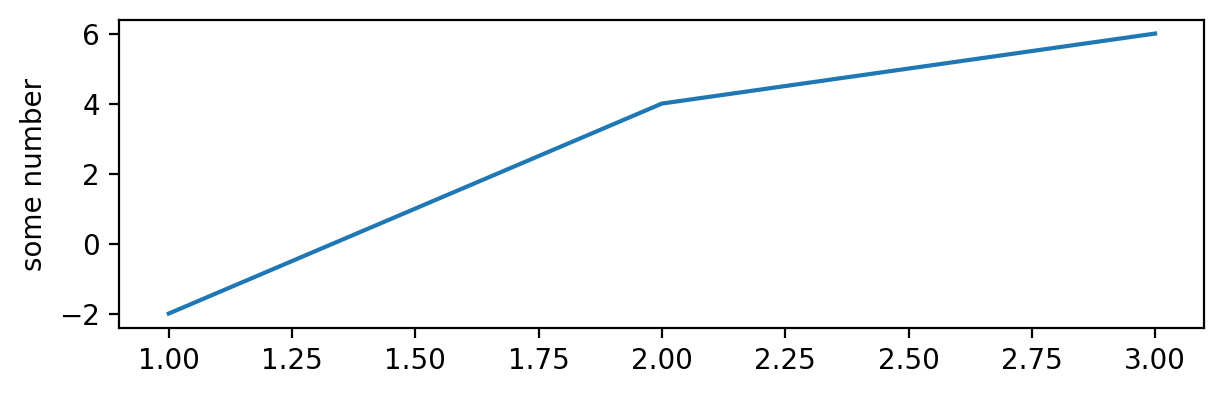

In [10]:
x = [1,2,3] # 1) 데이터 준비
y = [-2,4,6]
plt.figure(figsize=(7,2)) # 2) 그래프 객체 생성
plt.plot(x,y) # 3) 그래프 함수
plt.ylabel('some number') # 4) 커스터마이징
plt.show() # 5) 그래프 화면 출력 cf)plt.savefig('파일명.jpg')

## 1.3 그래프 영역 나누기
### 1) subplot()함수로 서프플롯 추가

In [11]:
import numpy as np
x = np.arange(0,10,0.01)
len(x)

1000

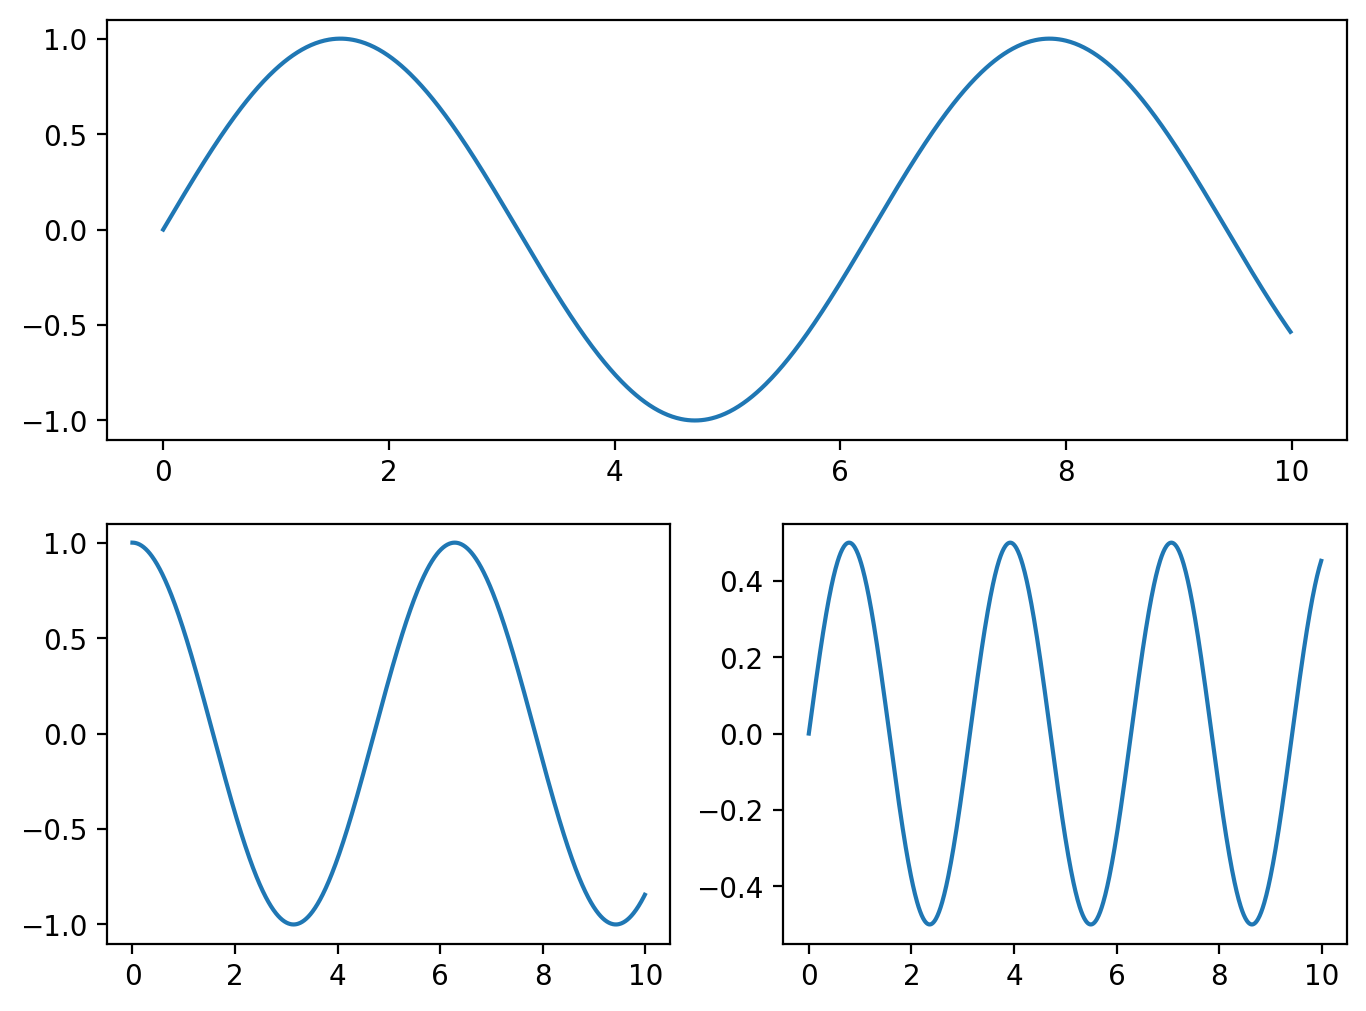

In [16]:
plt.figure(figsize=(8,6))
plt.subplot(2,1,1); plt.plot(x,np.sin(x))
plt.subplot(2,2,3); plt.plot(x,np.cos(x))
plt.subplot(224); plt.plot(x,np.sin(x)*np.cos(x))

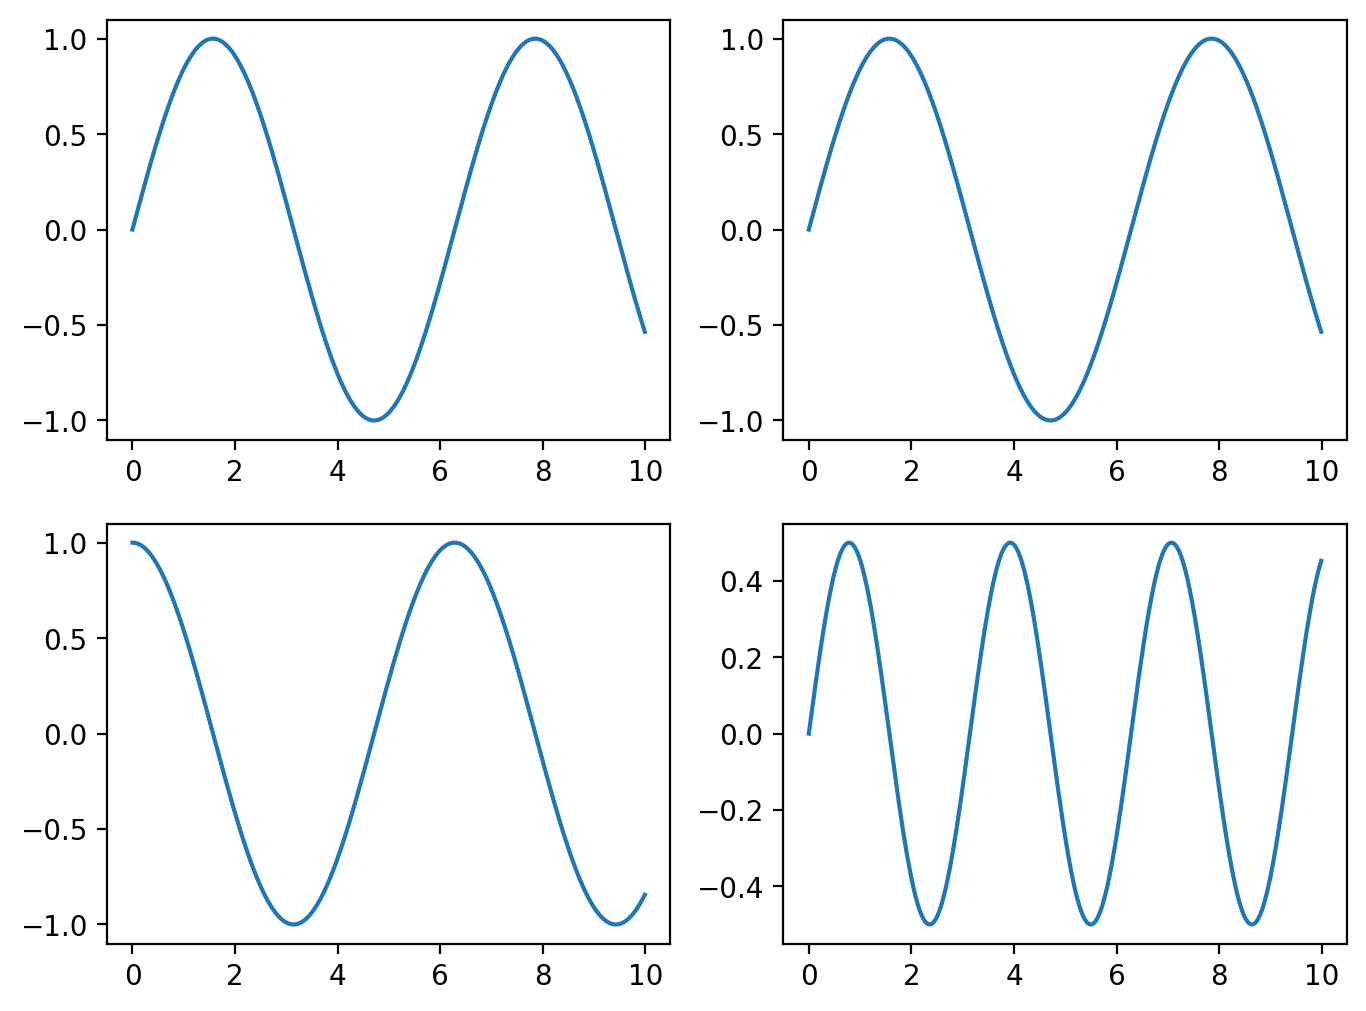

In [17]:
plt.figure(figsize=(8,6))
plt.subplot(2,2,1); plt.plot(x,np.sin(x))
plt.subplot(2,2,2); plt.plot(x,np.sin(x))
plt.subplot(2,2,3); plt.plot(x,np.cos(x))
plt.subplot(2,2,4); plt.plot(x,np.sin(x)*np.cos(x))

### 2) subplots()함수로 서브플롯 추가
- 교안(14page) : https://wikidocs.net/92085

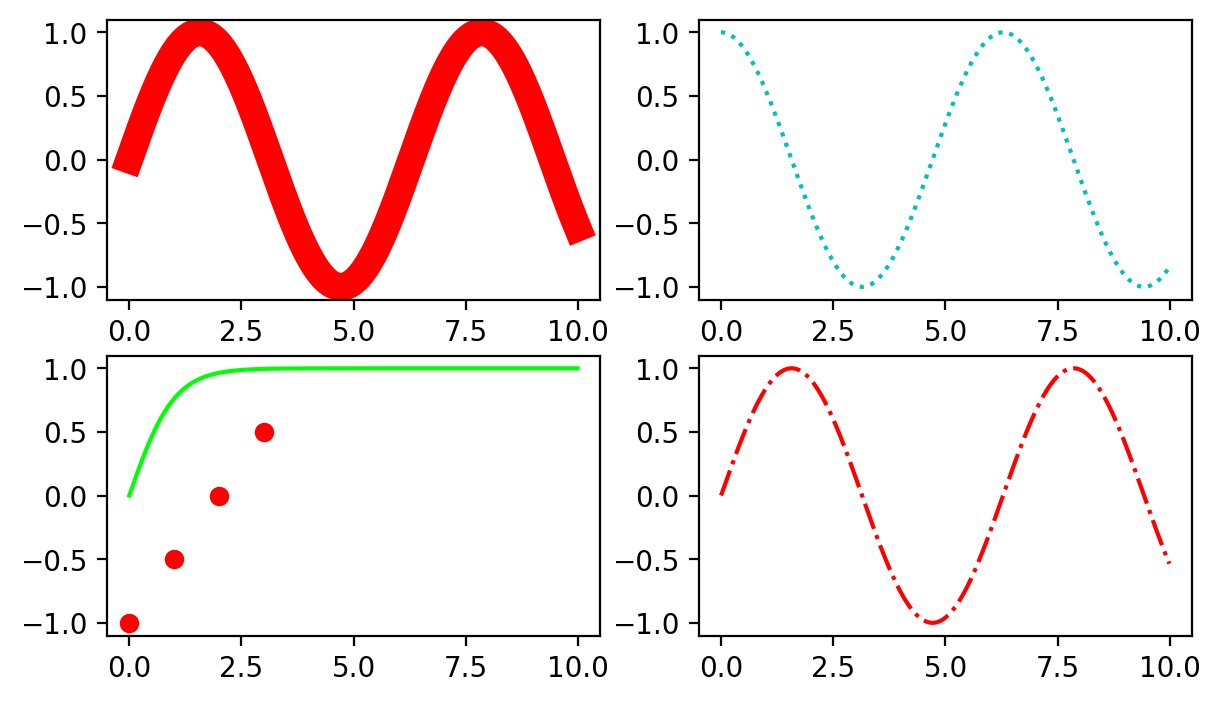

In [27]:
# 2행 2열 서브플롯
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7,4))
axes[0,0].plot(x, np.sin(x), 'r', linewidth=10)
axes[0,1].plot(x, np.cos(x), 'c:') # color='c', linestyle':','--','-'
axes[1,0].plot([0,1,2,3],[-1,-0.5,0,0.5], 'ro') #marker='o'
axes[1,0].plot(x, np.tanh(x), '#00FF00')
axes[1,1].plot(x, np.sin(x), 'r-.')
plt.show()

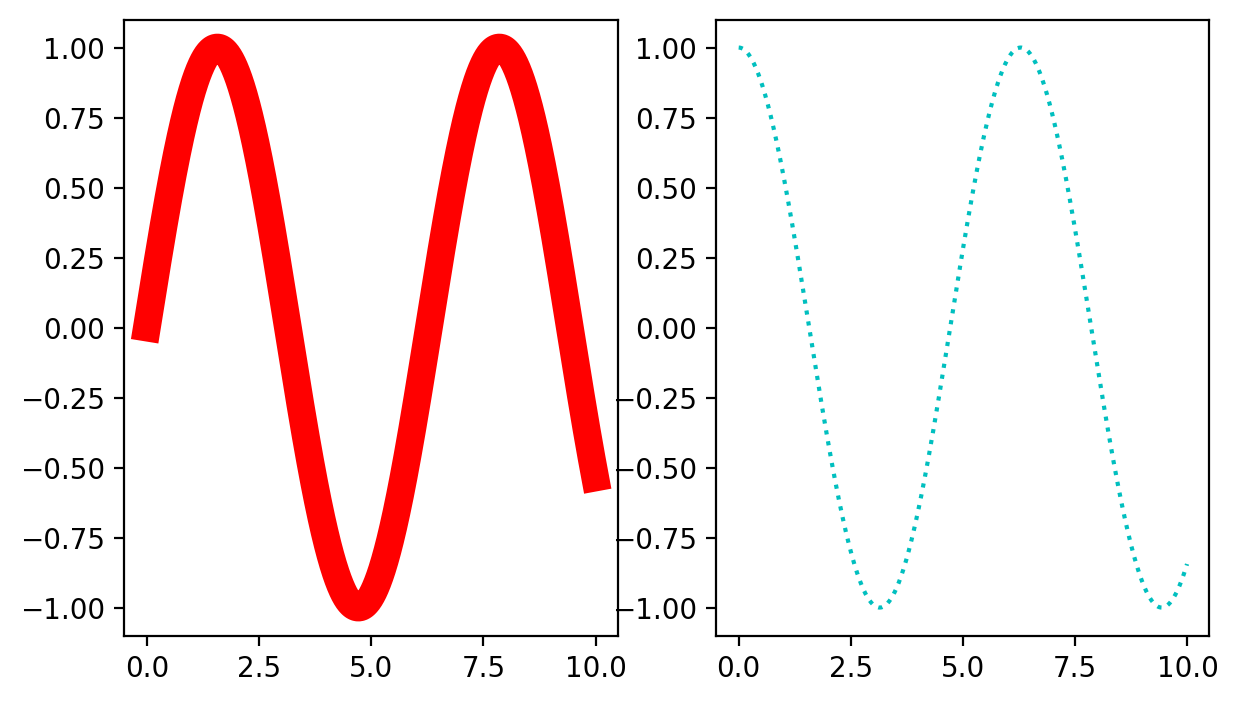

In [30]:
# 2행 2열 서브플롯
fig, axes = plt.subplots(ncols=2, figsize=(7,4))
axes[0].plot(x, np.sin(x), 'r', linewidth=10)
axes[1].plot(x, np.cos(x), 'c:') # color='c', linestyle':','--','-'

### 3) pandas.DataFrame.plot()
- plt.plot(x,y,fmt)
- df.plot(x=열이름, y=열이름, kind='line' figsize, title, xlim, ylim...)
    * kind : line(기본값), scatter(점도표), bar, barh, box, pie, density,...
    * xlim, ylim : list/tuple

In [31]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
41,4.5,2.3,1.3,0.3,setosa


In [ ]:
범례사용

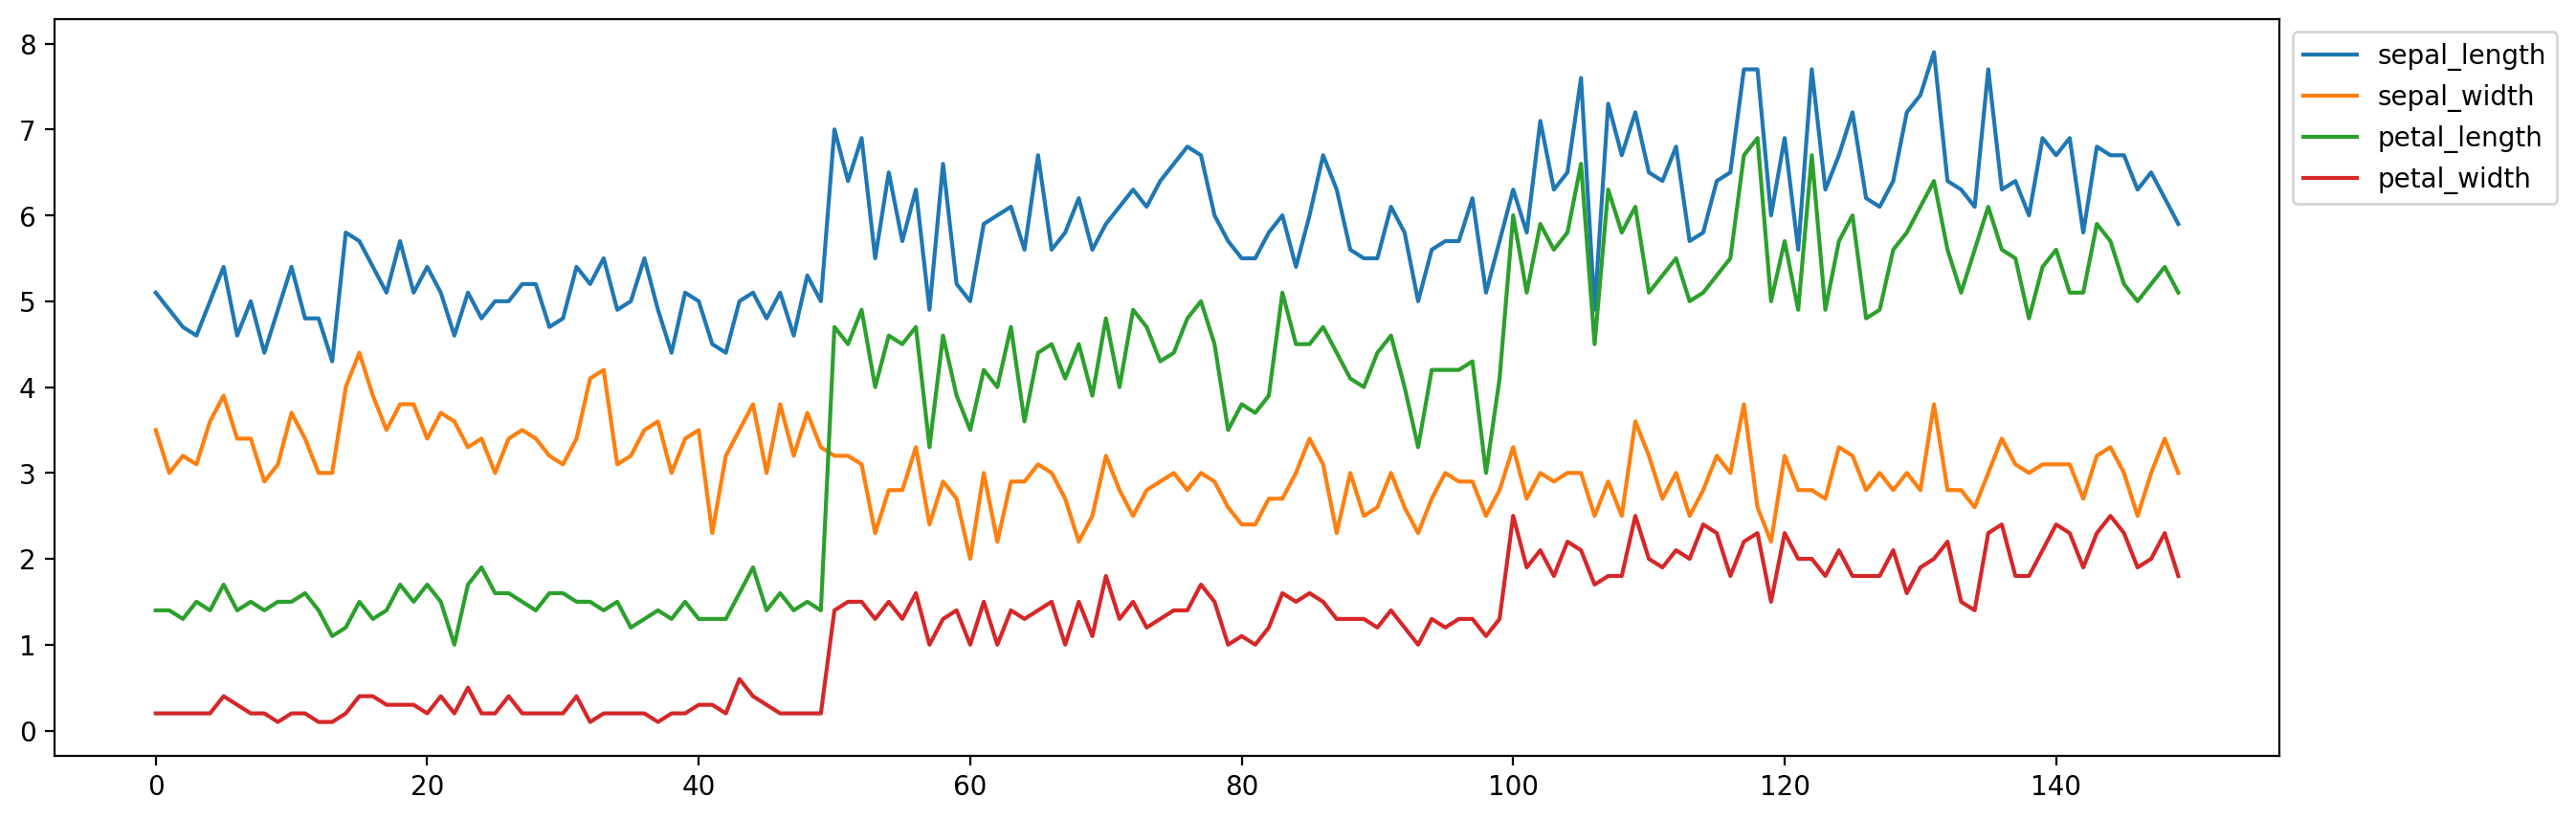

In [43]:
g= iris.plot(kind='line', figsize=(15,5))
# g.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('data/ch12_iris.jpg')
plt.show()

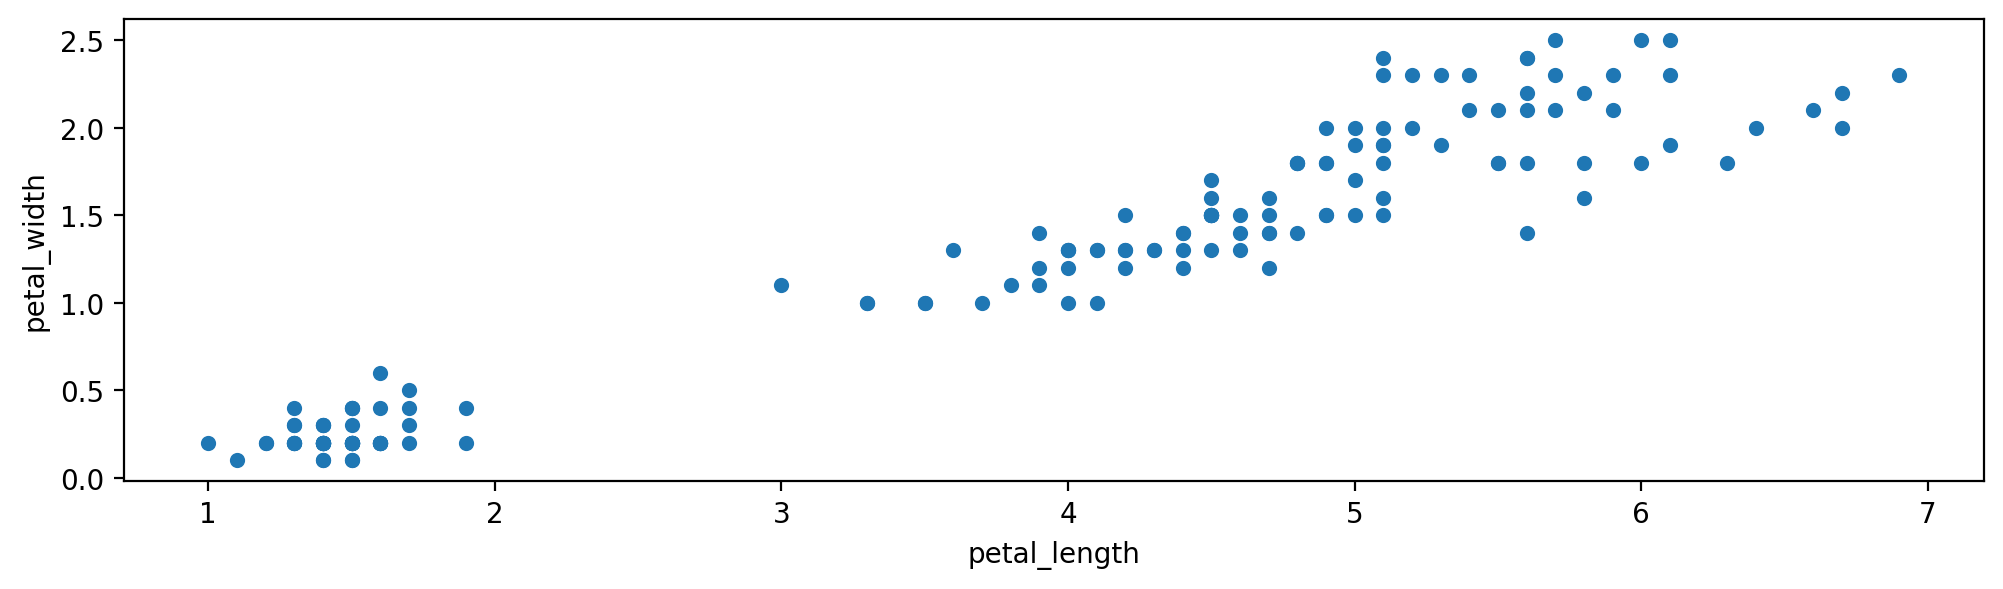

In [47]:
iris.plot(x='petal_length', y='petal_width', kind='scatter', figsize=(12, 3))
plt.show()

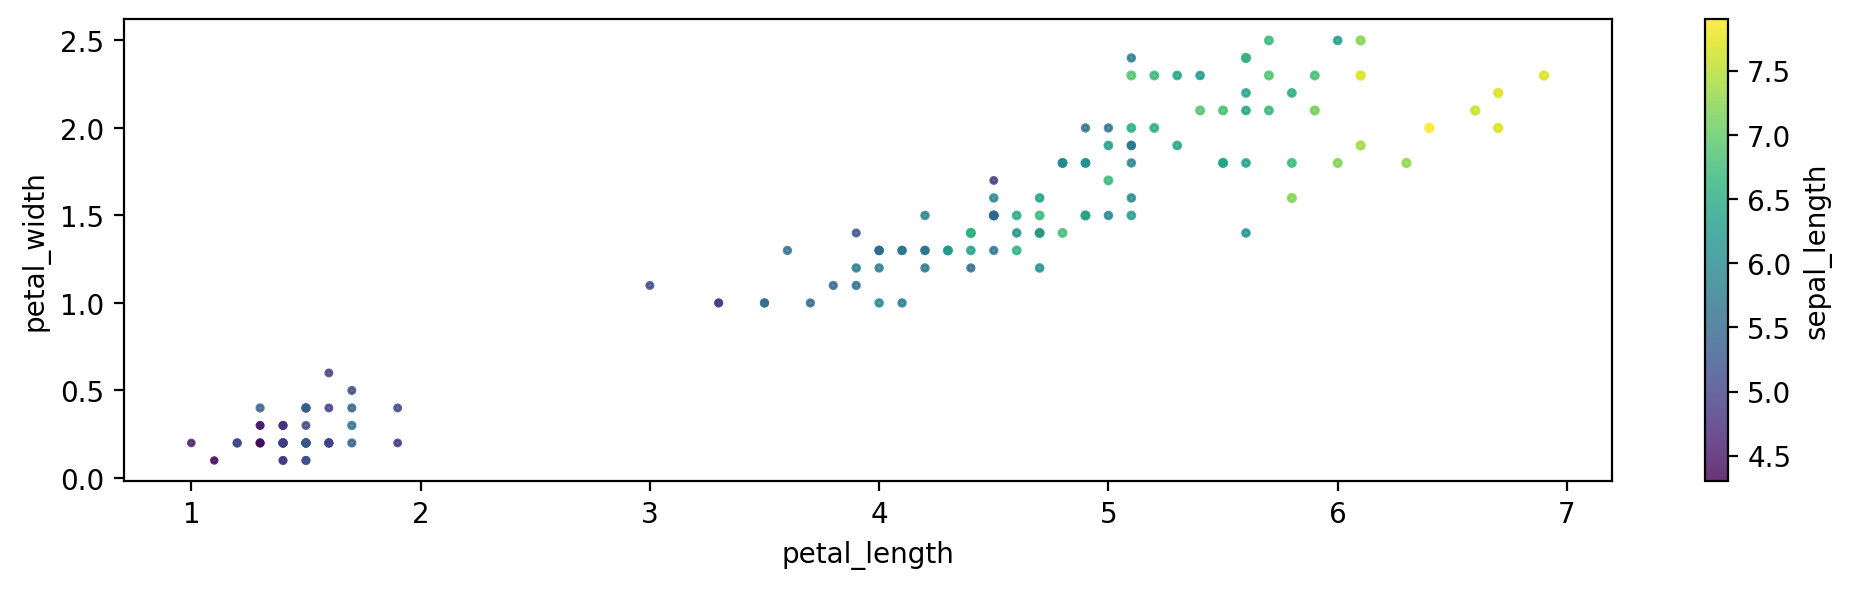

In [49]:
iris.plot(kind='scatter',
          x='petal_length',
          y='petal_width',
          figsize=(12, 3),
          s='sepal_length', # size
          c='sepal_length', # color
          alpha=.8) # 0<=투명도<=1
plt.show()

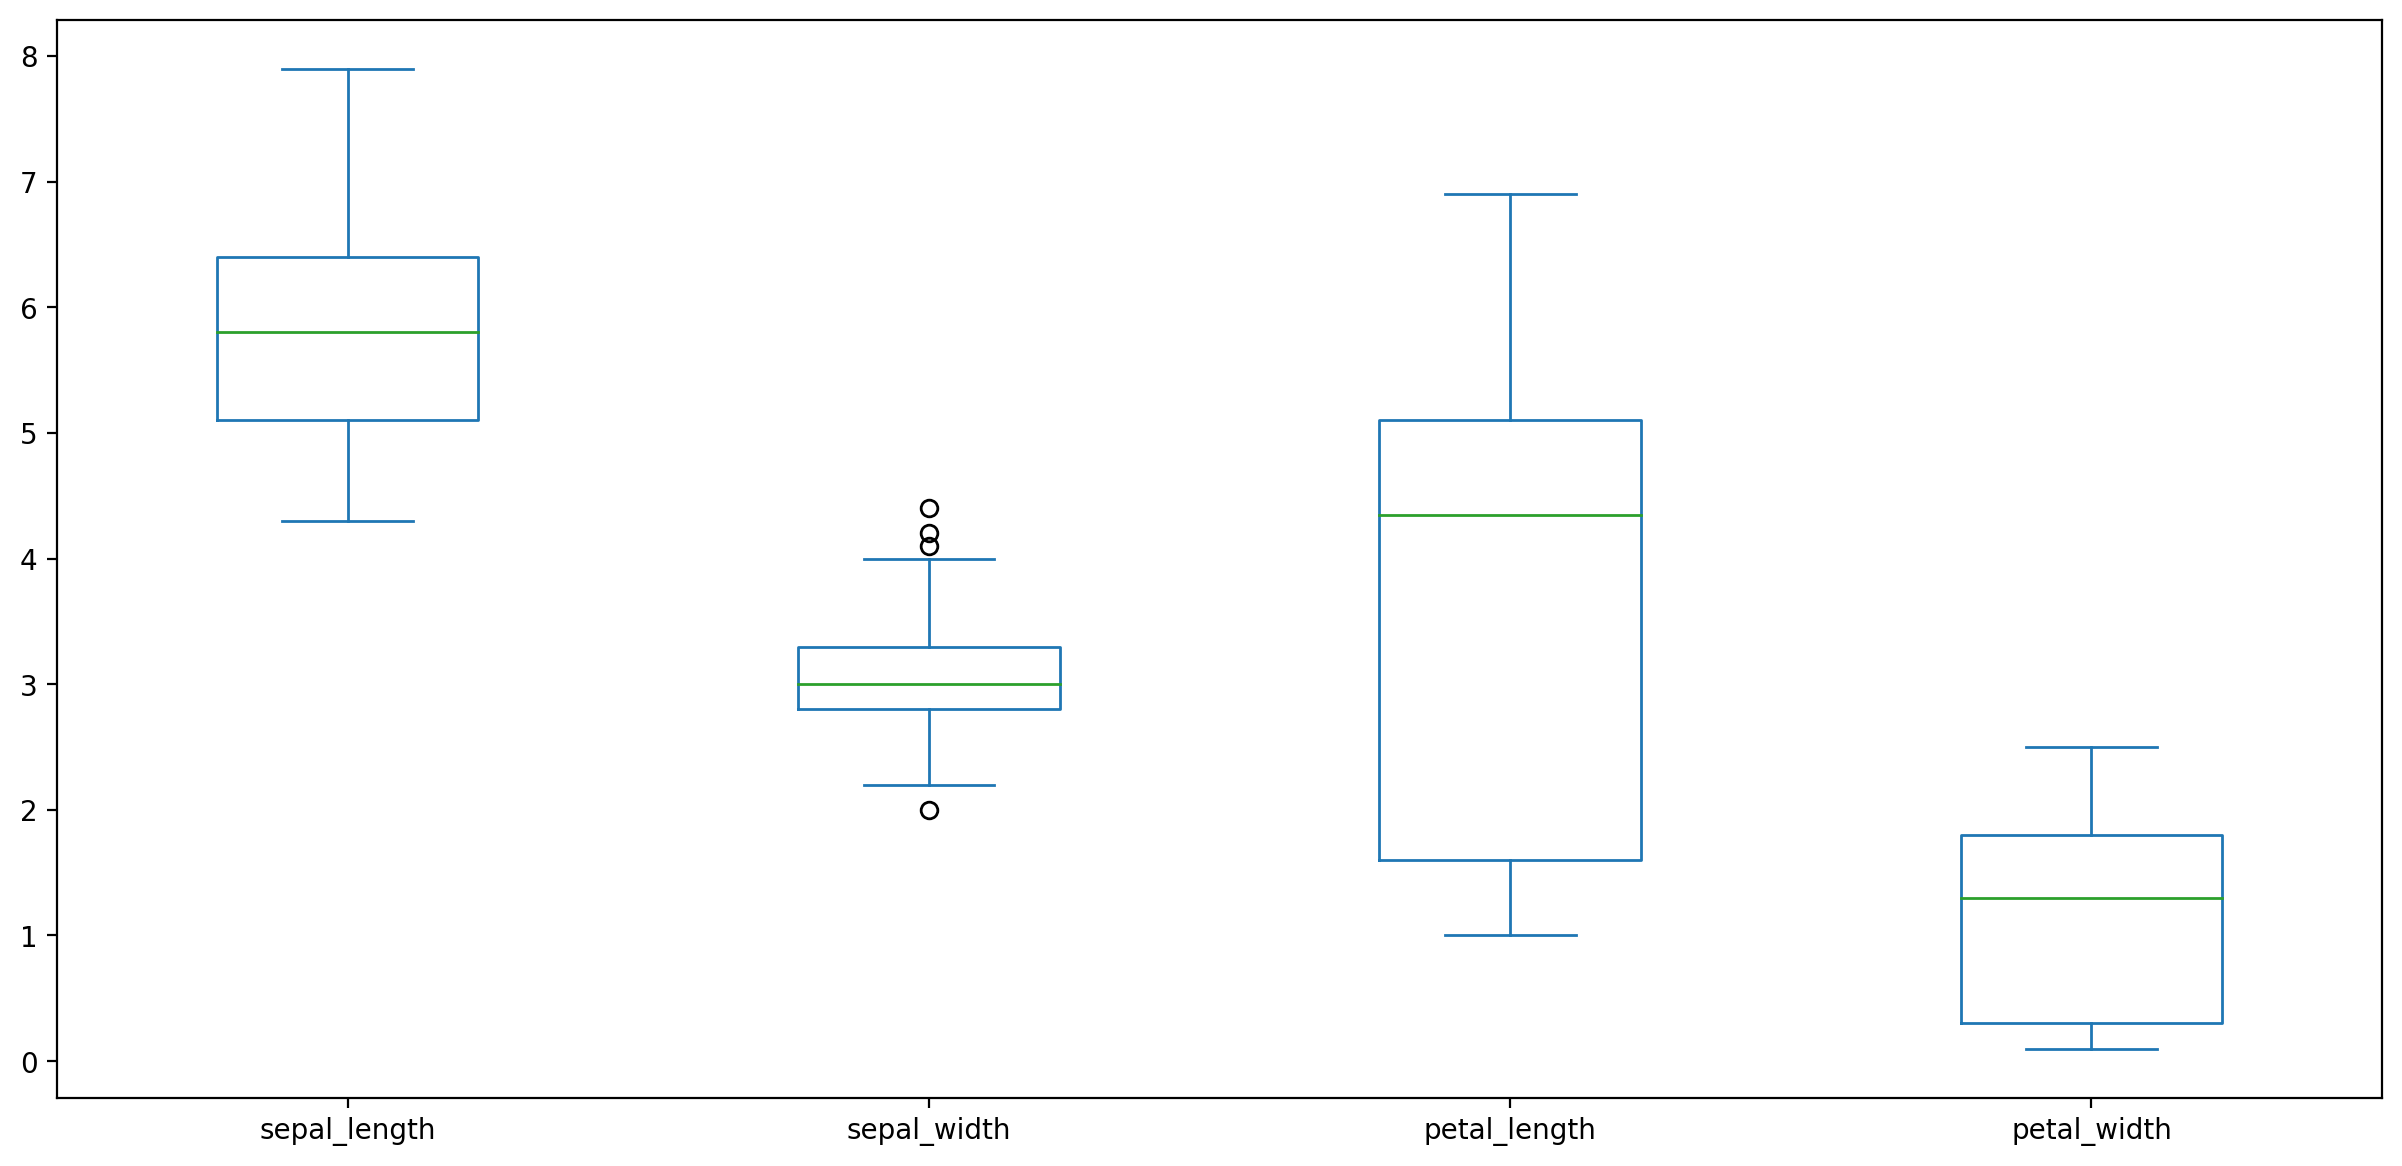

In [51]:
# 모든 열의 boxplot(이상치 여부, q1, q2, q3, min, max)
iris.plot(kind='box', figsize=(15,7))
plt.show()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,"Axes(0.125,0.653529;0.168478x0.226471)","Axes(0.327174,0.653529;0.168478x0.226471)","Axes(0.529348,0.653529;0.168478x0.226471)","Axes(0.731522,0.653529;0.168478x0.226471)"
versicolor,"Axes(0.125,0.653529;0.168478x0.226471)","Axes(0.327174,0.653529;0.168478x0.226471)","Axes(0.529348,0.653529;0.168478x0.226471)","Axes(0.731522,0.653529;0.168478x0.226471)"
virginica,"Axes(0.125,0.653529;0.168478x0.226471)","Axes(0.327174,0.653529;0.168478x0.226471)","Axes(0.529348,0.653529;0.168478x0.226471)","Axes(0.731522,0.653529;0.168478x0.226471)"


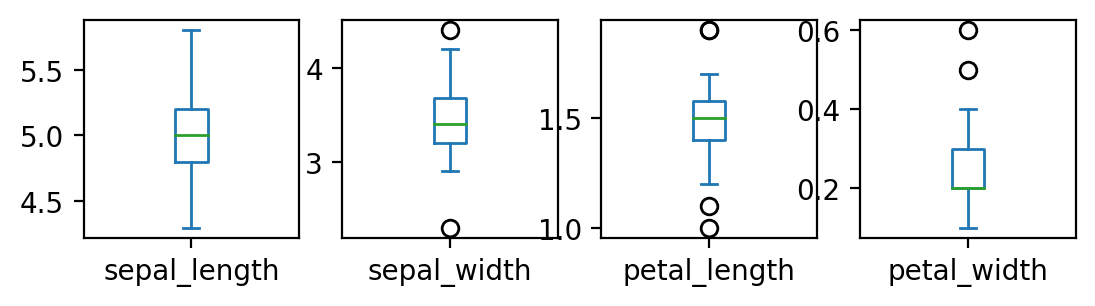

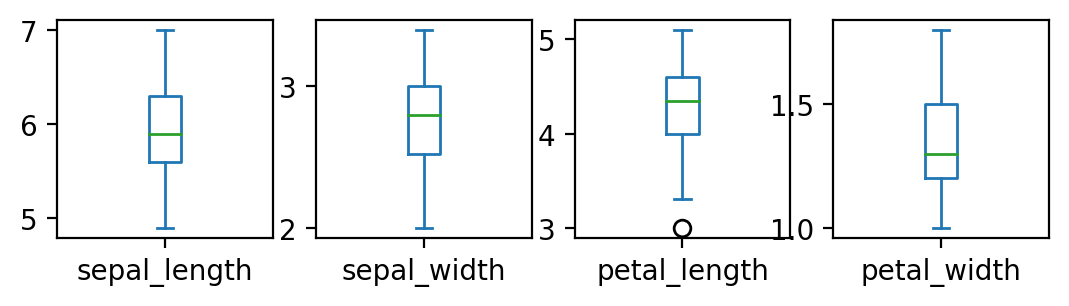

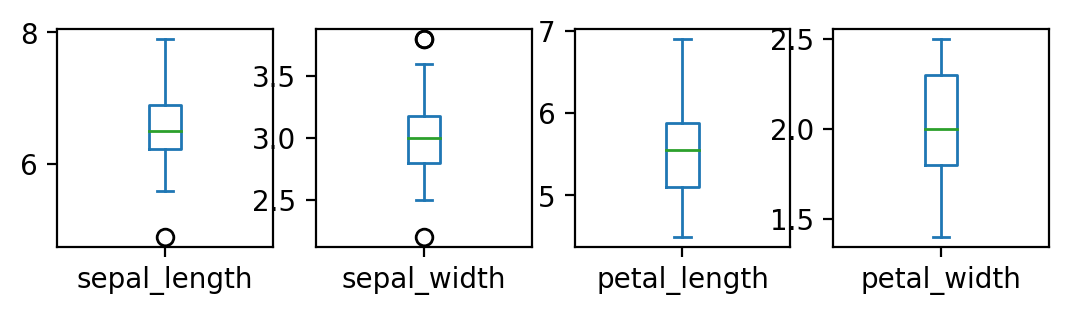

In [55]:
# 종별 boxplot
iris.groupby('species').plot(kind='box',
                             subplots=True,
                             layout=(3,4),
                             sharex=True) # x축공유

## 1.4 다양한  그래프 그리기
- pyplot함수들 : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.scatter.html
### 1) plt.scatter() : 산점도

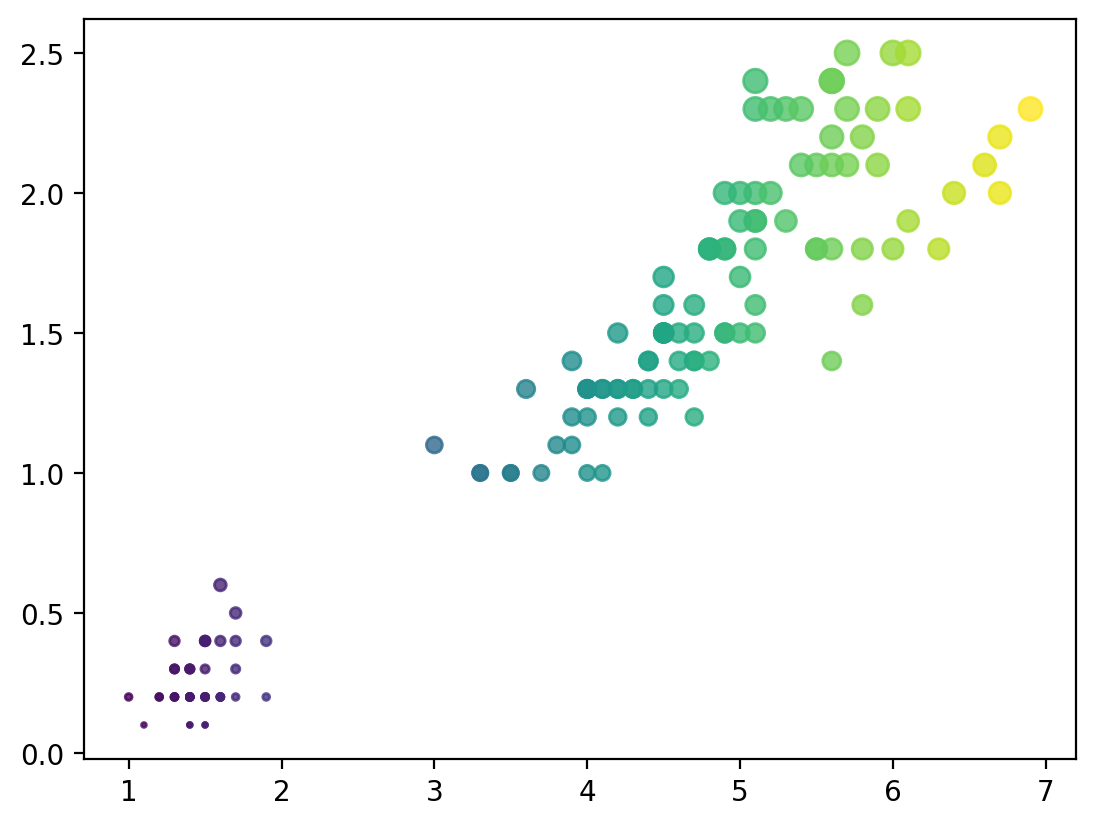

In [56]:
plt.scatter(iris.petal_length, iris.petal_width,
           s=iris.petal_width*30,   # size
           c=iris.petal_length*20,  # color
           alpha=.8)

### 2) boxplot(단점:분포를 몰라), violinplot()

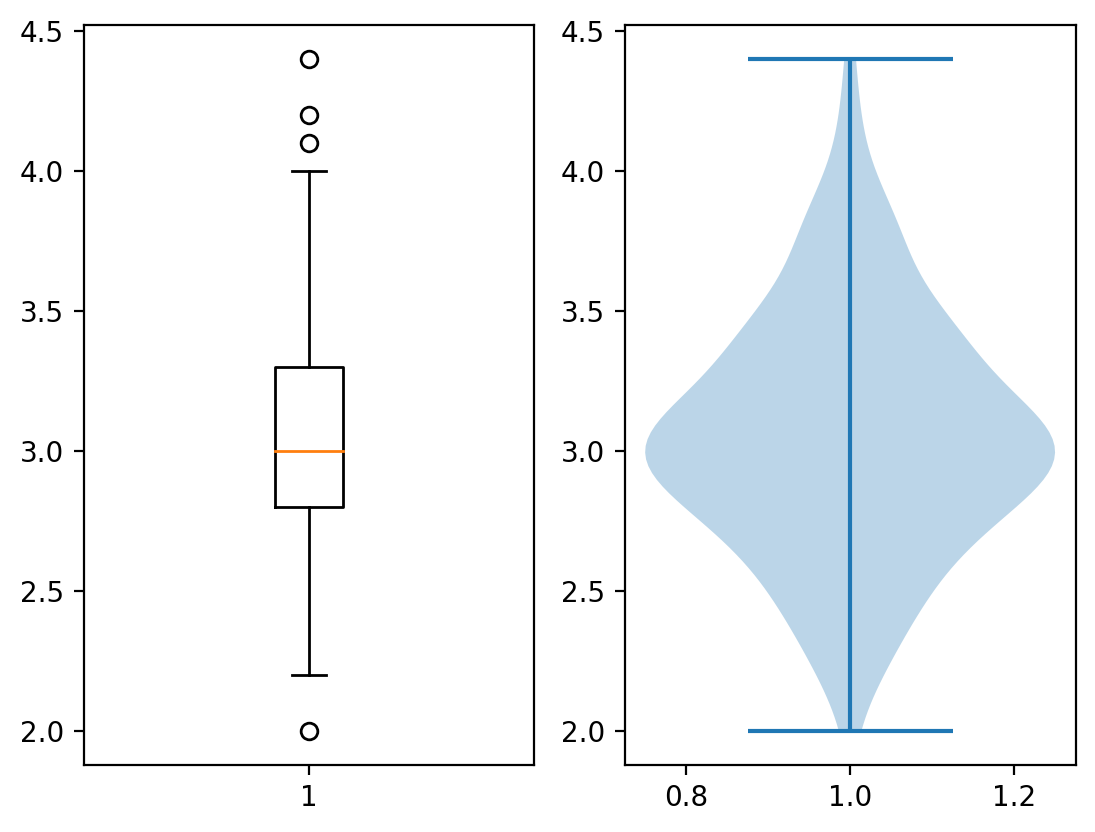

In [59]:
fig, axes = plt.subplots(ncols=2)
axes[0].boxplot(iris.sepal_width)
axes[1].violinplot(iris.sepal_width)
plt.show()

### 3) bar(), barh(),axvline(수직선), axhline(수평선)

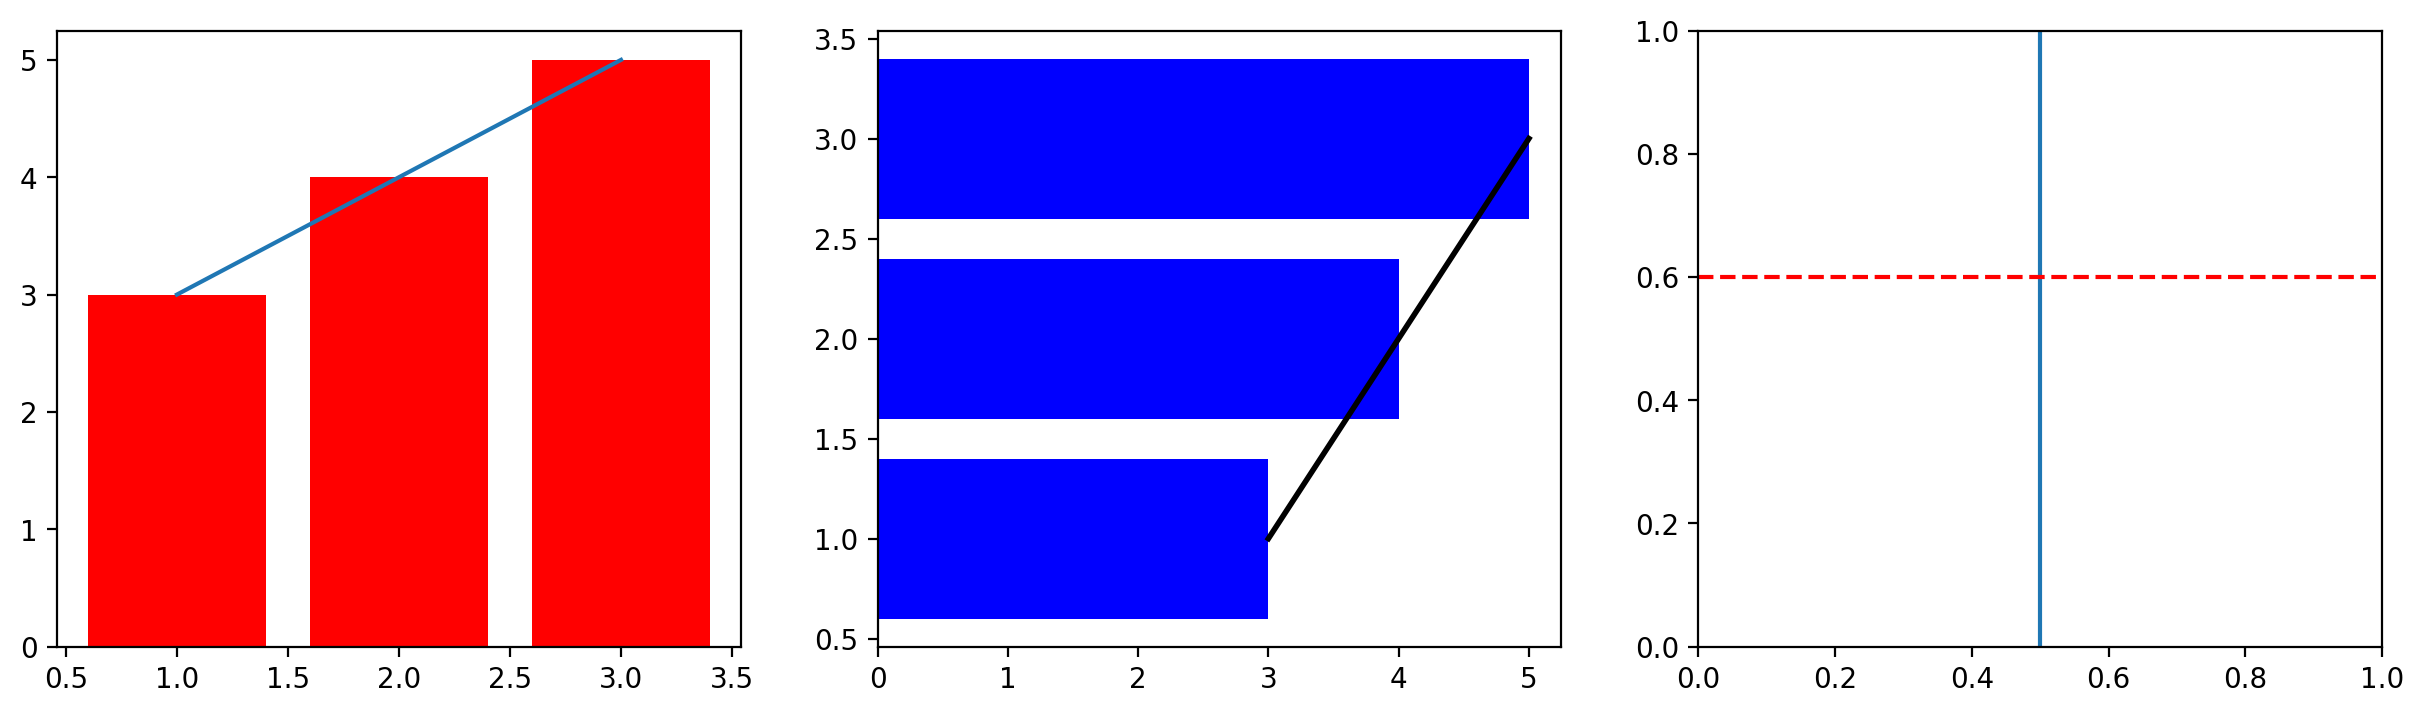

In [61]:
x=[1,2,3]
y=[3,4,5]
fig, axes = plt.subplots(ncols=3, figsize=(15,4))
axes[0].bar(x,y,color='r')
axes[0].plot(x,y)
axes[1].barh(x,y,color='b')
axes[1].plot(y,x,'k', linewidth=2) # k:black
axes[2].axvline(0.5)
axes[2].axhline(0.6, c='r', linestyle='--')

### 4) hist(도수분포표;histogram)

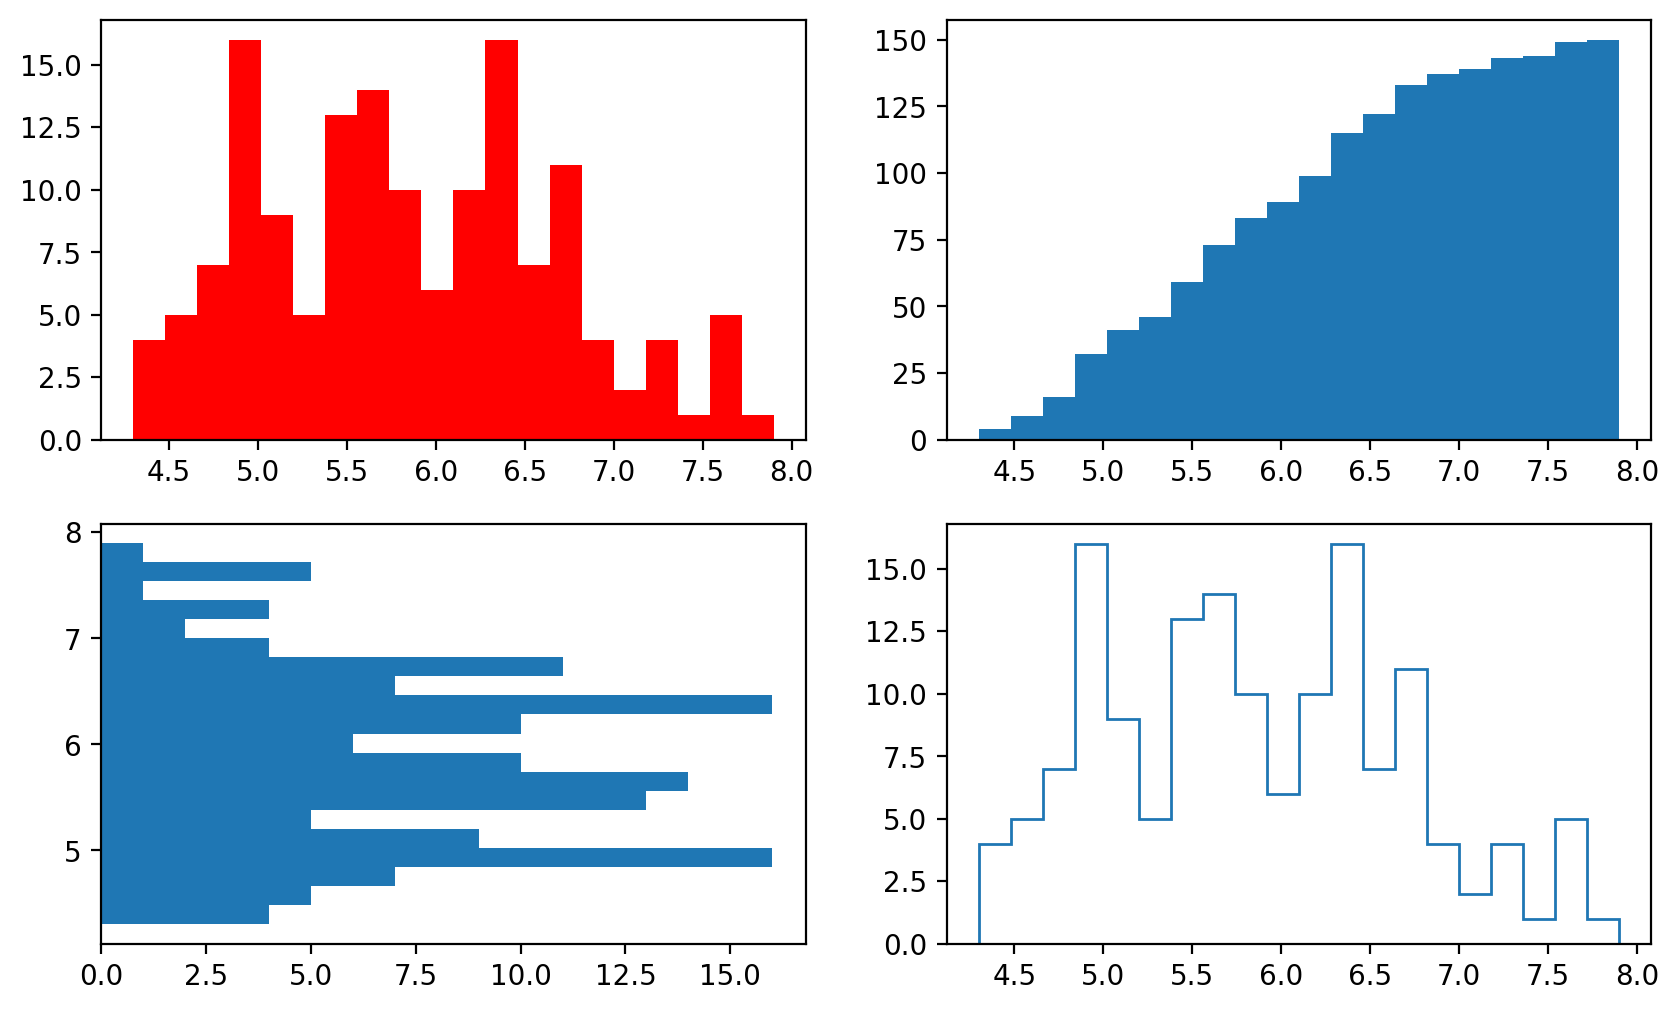

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,6))
axes[0,0].hist(iris.sepal_length, bins=20, color='r') # 히스토그램(도수분포표)
axes[0,1].hist(iris.sepal_length, bins=20, cumulative=True) # 누적히스토그램
axes[1,0].hist(iris.sepal_length, bins=20, orientation='horizontal') # 수평히스토그램
axes[1,1].hist(iris.sepal_length, bins=20, histtype='step') 
plt.show()

## 1.5 그래프 커스터마이징
### 1) linestyle, linewidth, color, marker...(plot의 매개변수로 지정)
### 2) text(), annotate()

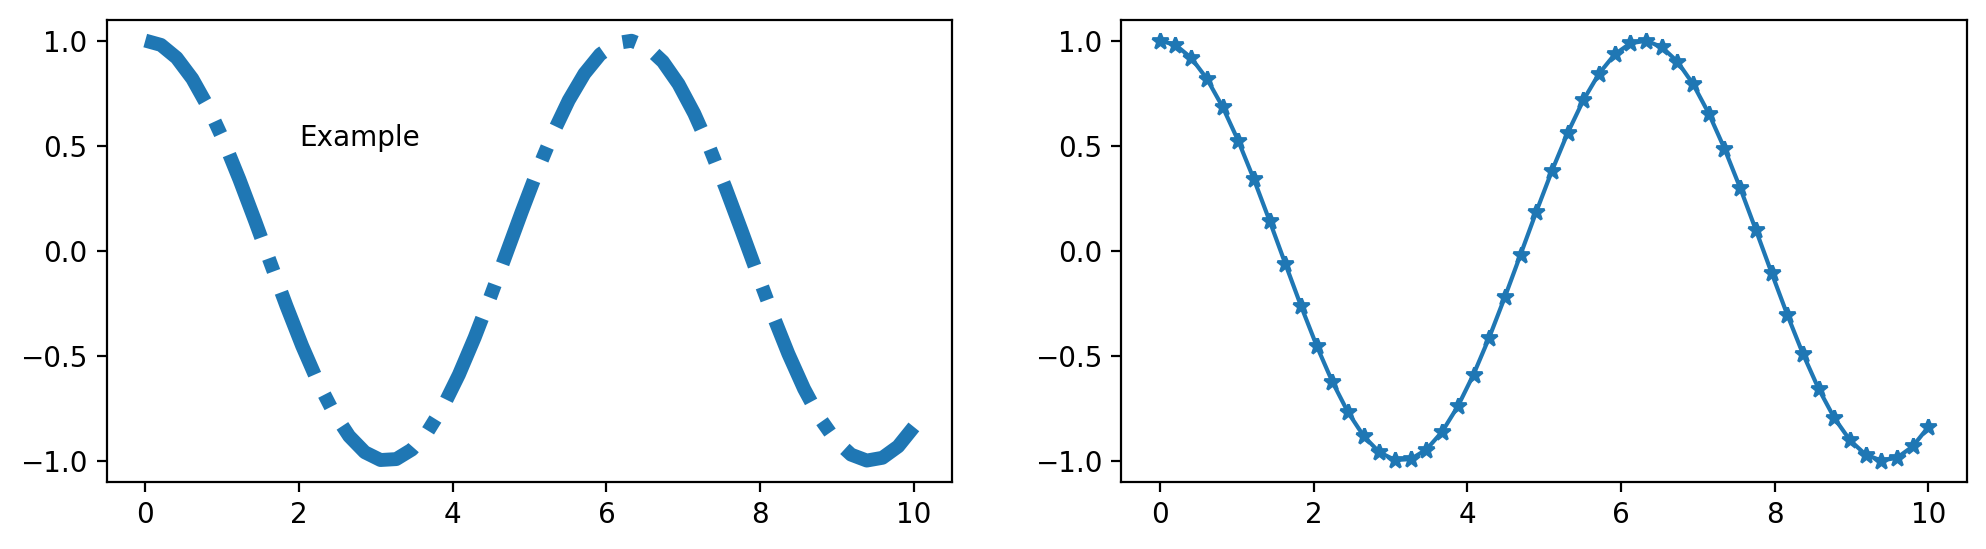

In [73]:
x = np.linspace(0,10) # num=50
y = np.cos(x)
fig, axes = plt.subplots(1,2,figsize=(12,3))
axes[0].plot(x,y, linewidth=5, linestyle='-.')
axes[0].text(2, 0.5, 'Example')
axes[1].plot(x,y,marker='*')
plt.show()